In [1]:
import ast
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src_global.utils import blob, constant

PROJECT_PREFIX = constant.PROJECT_PREFIX

## Analysis

In [ ]:
len(blob.list_container_blobs(name_starts_with='global_model/IBTRACKS/wind_data_part_'))

In [6]:
impact_data = pd.read_csv("/data/big/fmoss/data/EMDAT/global_grid_impact_data.csv")

In [5]:
len(impact_data)

785011

In [3]:
# impact_data = blob.get_impact_data_at_grid_level()
# impact_data = pd.read_csv('impact_data.csv')
impact_data = pd.read_csv('/home/fmoss/GLOBAL MODEL/ds-glb-cyclones-impactmodel/src_global/datasources/01-EMDAT/grid_based_impact_data.csv')
# impact_data = pd.read_csv('/home/fmoss/GLOBAL MODEL/ds-glb-cyclones-impactmodel/src_global/datasources/01-EMDAT/grid_based_impact_data_weather_constraints.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/home/fmoss/GLOBAL MODEL/ds-glb-cyclones-impactmodel/src_global/datasources/01-EMDAT/grid_based_impact_data.csv'

In [40]:
impact_data.GID_0.unique()

array(['COL', 'CRI', 'DJI', 'DOM', 'GTM', 'HND', 'IDN', 'KHM', 'BRA',
       'LAO', 'LKA', 'NZL', 'PAN', 'PRK', 'SLV', 'SOM', 'TLS', 'TZA',
       'VEN', 'VNM', 'ZAF', 'TON', 'SLB', 'FSM', 'BRB', 'GRD', 'MUS'],
      dtype=object)

In [4]:
impact_data[impact_data.GID_0=='HTI']

,DisNo.,sid,level,population,id,GID_0,GID_1,GID_2,Total Affected,typhoon_name,typhoon_year,wind_speed,track_distance,iso3,rainfall_max_24h,perc_affected_pop_grid_region,perc_affected_pop_grid_grid,perc_affected_pop_grid


In [3]:
population_data = blob.get_population_data()

In [4]:
def get_wind_data():
    # Load data (is in chunks)
    filenames = [
        f"wind_data_part_{i}.csv" for i in range(1, 184)
    ]
    dataframes = []
    for filename in filenames:
        csv_path = f"{PROJECT_PREFIX}/IBTRACKS/{filename}"
        df = blob.load_csv(csv_path=csv_path)
        dataframes.append(df)
    wind_data = pd.concat(dataframes, ignore_index=True)
    return wind_data

# wind_data = get_wind_data()

In [5]:
def get_rain_data():
    # Load data (is in chunks)
    filenames = [
        f"rainfall_data_part_{i}.csv" for i in range(1, 174)
    ]
    dataframes = []
    for filename in filenames:
        csv_path = f"{PROJECT_PREFIX}/PPS/{filename}"
        df = blob.load_csv(csv_path=csv_path)
        dataframes.append(df)
    rain_data = pd.concat(dataframes, ignore_index=True)
    return rain_data

# rain_data = get_rain_data()

In [6]:
rain_data = pd.read_csv('/home/fmoss/GLOBAL MODEL/ds-glb-cyclones-impactmodel/src_global/datasources/05-PPS/rainfall_data.csv')

In [7]:
wind_data = pd.read_csv('/home/fmoss/GLOBAL MODEL/ds-glb-cyclones-impactmodel/src_global/datasources/wind_data.csv')

In [11]:
wind_data.iso3.unique()

array(['ATG', 'PAK', 'MEX', 'GRD', 'JPN', 'TZA', 'ZWE', 'IND', 'SLB',
       'KOR', 'PRK', 'FSM', 'CRI', 'OMN', 'BRB', 'MMR', 'MTQ', 'VNM',
       'LKA', 'DJI', 'IDN', 'PAN', 'NCL', 'PYF', 'SLV', 'FJI', 'VUT',
       'BHS', 'MUS', 'USA', 'AUS', 'GTM', 'GLP', 'KHM', 'BLZ', 'CAN',
       'MWI', 'IRN', 'NIC', 'BRA', 'THA', 'WSM', 'BGD', 'HND', 'VEN',
       'CUB', 'MOZ', 'PNG', 'MDG', 'TON', 'YEM', 'TWN', 'PRT', 'DOM',
       'PHL', 'TLS', 'CHN', 'LAO', 'NZL', 'ZAF', 'SOM', 'COL'],
      dtype=object)

Mock up data

In [25]:
rain_data_mock = rain_data[rain_data.iso3.isin(['ATG','FJI'])]
wind_data_mock = wind_data[wind_data.iso3.isin(['ATG','FJI'])]
impact_data_mock = impact_data[impact_data.GID_0.isin(['ATG','FJI'])]

In [ ]:
# Merge weather data (wind and rainfall)
weather_data_merged_mock = wind_data_mock.rename(
    {'grid_point_id':'id', 'track_id':'sid'}, 
     axis=1).merge(rain_data_mock)
# Merge with impact data
impact_weather_merged_mock = weather_data_merged_mock.merge(impact_data_mock)
# Merge with population data
input_data_mock = impact_weather_merged_mock.merge(population_data)


Some analysis

In [ ]:
rain_events = rain_data[['sid', 'iso3']].drop_duplicates().reset_index(drop=True)
wind_events = wind_data[['track_id', 'iso3']].drop_duplicates().rename(
    {'track_id':'sid'}, axis=1).reset_index(drop=True)
impact_events = impact_data[['sid', 'GID_0']].drop_duplicates().rename(
    {'GID_0':'iso3'}, axis=1).reset_index(drop=True)

In [ ]:
# 1. Common events between rain_events and wind_events
common_rain_wind = pd.merge(rain_events, wind_events, on=['sid', 'iso3'])

# 2. Events in rain_events but not in wind_events
rain_not_in_wind = pd.merge(rain_events, wind_events, on=['sid', 'iso3'], how='left', indicator=True)
rain_not_in_wind = rain_not_in_wind[rain_not_in_wind['_merge'] == 'left_only'].drop('_merge', axis=1)

# 3. Events in wind_events but not in rain_events
wind_not_in_rain = pd.merge(wind_events, rain_events, on=['sid', 'iso3'], how='left', indicator=True)
wind_not_in_rain = wind_not_in_rain[wind_not_in_rain['_merge'] == 'left_only'].drop('_merge', axis=1)

# 4. Events in rain_events but not in impact_events
rain_not_in_impact = pd.merge(rain_events, impact_events, on=['sid', 'iso3'], how='left', indicator=True)
rain_not_in_impact = rain_not_in_impact[rain_not_in_impact['_merge'] == 'left_only'].drop('_merge', axis=1)

# 5. Events in impact_events but not in rain_events
impact_not_in_rain = pd.merge(impact_events, rain_events, on=['sid', 'iso3'], how='left', indicator=True)
impact_not_in_rain = impact_not_in_rain[impact_not_in_rain['_merge'] == 'left_only'].drop('_merge', axis=1)

# 6. Events in impact_events but not in wind_events
impact_not_in_wind = pd.merge(impact_events, wind_events, on=['sid', 'iso3'], how='left', indicator=True)
impact_not_in_wind = impact_not_in_wind[impact_not_in_wind['_merge'] == 'left_only'].drop('_merge', axis=1)



In [52]:
print(len(impact_not_in_rain))
impact_not_in_rain.head()

64


,sid,iso3
3,2000056S17152,AUS
9,2000091S14156,AUS
20,2022295N13093,BGD
173,2022008S17173,FJI
262,2022180N15130,JPN


Do these events take place before 06/2000?

In [ ]:
metadata_global = blob.load_csv("global_model/PPS/metadata/meta_data.csv")


In [73]:
metadata_global[metadata_global.sid=='2000056S17152']

,iso3,typhoon,sid,startdate,enddate,landfalldate,landfall_time,GID_0,DisNo.,Start Year,Event Name
372,AUS,STEVE2000,2000056S17152,2000-02-25,2000-03-11,2000-02-27,10:00:00,AUS,2000-0097-AUS,2000.0,Steve


In [74]:
metadata_global[metadata_global.sid=='2022008S17173']

,iso3,typhoon,sid,startdate,enddate,landfalldate,landfall_time,GID_0,DisNo.,Start Year,Event Name


In [75]:
metadata_global[metadata_global.sid=='2022180N15130']

,iso3,typhoon,sid,startdate,enddate,landfalldate,landfall_time,GID_0,DisNo.,Start Year,Event Name


Some events are not even present in the metadata. 

The metadata is built based on available wind data. So if the data is not ibtracks, then is not in the metadata and not in the rainfall dataset. 

In [51]:
print(len(impact_not_in_wind))
impact_not_in_wind.head()

52


,sid,iso3
20,2022295N13093,BGD
119,2022280N11294,COL
173,2022008S17173,FJI
215,2017242N16333,HTI
216,2002265N10315,HTI


Events missing in both datasets

In [56]:
set(rain_not_in_wind.sid.unique()) & set(wind_not_in_rain.sid.unique())

{'2004247N10332',
 '2004258N16300',
 '2007225N12331',
 '2008245N17323',
 '2010302N09306',
 '2011233N15301',
 '2021182N09317'}

Merge datasets

In [ ]:
# Merge weather data (wind and rainfall)
weather_data_merged = wind_data.rename(
    {'grid_point_id':'id', 'track_id':'sid'}, 
     axis=1).merge(rain_data)
# Merge with impact data
impact_weather_merged = weather_data_merged.merge(impact_data)
# Merge with population data
input_data_merged = impact_weather_merged.merge(population_data).reset_index(drop=True)


In [30]:
input_data_merged_clean = input_data_merged.drop(['GID_0', 'GID_1', 'GID_2'], axis=1).drop_duplicates()

Merge datasets (weather contraints)

In [18]:
# Merge with population data
input_data_merged = impact_data.merge(population_data).reset_index(drop=True)
input_data_merged_clean = input_data_merged.drop(['GID_0', 'GID_1', 'GID_2'], axis=1).drop_duplicates()


Unique data

In [9]:
unique_data = input_data_merged_clean[['sid', 'iso3']].drop_duplicates().reset_index(drop=True)

In [16]:
unique_data

,sid,iso3
0,2008287N15291,ATG
1,2010236N12341,ATG
2,2017242N16333,ATG
3,2009024S17123,AUS
4,2013018S14138,AUS
...,...,...
790,2000273N16277,BLZ
791,2001278N12302,BLZ
792,2002265N10315,BRB
793,2002265N10315,GRD


Duplicate analysis.. 

In [62]:
duplicates = input_data_merged[input_data_merged.duplicated(subset=['id', 'iso3', 'sid'], keep=False)]

In [65]:
duplicates[(duplicates.sid=='2019112S10053') & (duplicates.id=='TZA_1748')]

,typhoon_name,typhoon_year,sid,id,wind_speed,track_distance,iso3,rainfall_max_24h,DisNo.,level,population,GID_0,GID_1,GID_2,Total Affected,perc_affected_pop_grid_region,perc_affected_pop_grid
1325698,KENNETH,2019,2019112S10053,TZA_1748,0.0,1410.51064,TZA,2.28058,2019-0165-TZA,ADM1,0.0,TZA,TZA.8_1,TZA.8.8_1,0.0,0.0,0.0
1333718,KENNETH,2019,2019112S10053,TZA_1748,0.0,1410.51064,TZA,2.28058,2019-0165-TZA,ADM1,0.0,TZA,TZA.8_1,TZA.8.8_1,0.0,0.0,0.0
1341738,KENNETH,2019,2019112S10053,TZA_1748,0.0,1410.51064,TZA,2.28058,2019-0165-TZA,ADM1,0.0,TZA,TZA.8_1,TZA.8.8_1,0.0,0.0,0.0
1349758,KENNETH,2019,2019112S10053,TZA_1748,0.0,1410.51064,TZA,2.28058,2019-0165-TZA,ADM1,0.0,TZA,TZA.8_1,TZA.8.8_1,0.0,0.0,0.0
1357778,KENNETH,2019,2019112S10053,TZA_1748,0.0,1410.51064,TZA,2.28058,2019-0165-TZA,ADM1,0.0,TZA,TZA.8_1,TZA.8.8_1,0.0,0.0,0.0
1365798,KENNETH,2019,2019112S10053,TZA_1748,0.0,1410.51064,TZA,2.28058,2019-0165-TZA,ADM1,0.0,TZA,TZA.8_1,TZA.8.8_1,0.0,0.0,0.0
1373818,KENNETH,2019,2019112S10053,TZA_1748,0.0,1410.51064,TZA,2.28058,2019-0165-TZA,ADM1,0.0,TZA,TZA.8_1,TZA.8.8_1,0.0,0.0,0.0


They are really duplicates. 

Save merged dataset

In [31]:
input_data_merged_clean = input_data_merged_clean.reset_index(drop=True)

In [32]:
input_data_merged_clean.head()

,typhoon_name,typhoon_year,sid,id,wind_speed,track_distance,iso3,rainfall_max_24h,DisNo.,level,population,Total Affected,perc_affected_pop_grid_homo,perc_affected_pop_grid_region,perc_affected_pop_grid_grid,perc_affected_pop_grid
0,NOT_NAMED,2004,2004086S29318,BRA_4244,0.0,3541.538087,BRA,5.751530,2004-0131-BRA,ADM2,10.954744,0.0,0.0,0.0,0.0,0.0
1,NOT_NAMED,2004,2004086S29318,BRA_4245,0.0,3534.176520,BRA,5.741568,2004-0131-BRA,ADM2,17.042420,0.0,0.0,0.0,0.0,0.0
2,NOT_NAMED,2004,2004086S29318,BRA_4246,0.0,3526.834586,BRA,4.387294,2004-0131-BRA,ADM2,24.428259,0.0,0.0,0.0,0.0,0.0
3,NOT_NAMED,2004,2004086S29318,BRA_4247,0.0,3519.512406,BRA,4.222424,2004-0131-BRA,ADM2,66.467550,0.0,0.0,0.0,0.0,0.0
4,NOT_NAMED,2004,2004086S29318,BRA_4655,0.0,3533.233412,BRA,3.168394,2004-0131-BRA,ADM2,14.562319,0.0,0.0,0.0,0.0,0.0


In [33]:
input_data_merged_clean = input_data_merged_clean.rename(
    {'perc_affected_pop_grid':'perc_affected_pop_grid_weighted'}, 
    axis=1)

In [34]:
input_data_merged_clean.to_csv('model_input_data.csv', index=False)

In [29]:
# input_data_merged_clean = pd.read_csv('model_input_data.csv')

In [15]:
# Save to blob
blob.upload_in_chunks(
    dataframe=input_data_merged_clean,
    chunk_size=100000,
    blob=blob,
    blob_name_template="model_input_data",
    folder="model_input",
    #project_prefix='global_model'
)

## Easy doing

In [9]:
population_data = blob.get_population_data()
rain_data = pd.read_csv('/home/fmoss/GLOBAL MODEL/ds-glb-cyclones-impactmodel/src_global/datasources/05-PPS/rainfall_data.csv')
wind_data = pd.read_csv('/home/fmoss/GLOBAL MODEL/ds-glb-cyclones-impactmodel/src_global/datasources/wind_data.csv')

In [ ]:
flood_risk = pd.read_csv('/home/fmoss/GLOBAL MODEL/data/FloodRisk/global_flood_risk_index.csv')
landslide_risk = pd.read_csv('/home/fmoss/GLOBAL MODEL/data/landslides/global_landslide_risk_index.csv')
static_risks = flood_risk.merge(landslide_risk[['id', 'iso3', 'landslide_risk_sum']])

In [22]:
vulnerability_meta = pd.read_csv('/home/fmoss/GLOBAL MODEL/data/vulnerability_from_metadata/metadata_vulnerability_feature.csv')

In [ ]:
# NO WEATHER CONSTRAINTS
impact_data = pd.read_csv('/home/fmoss/GLOBAL MODEL/ds-glb-cyclones-impactmodel/src_global/datasources/01-EMDAT/grid_based_impact_data.csv')

# Merge weather data (wind and rainfall)
weather_data_merged = wind_data.rename(
    {'grid_point_id':'id', 'track_id':'sid'}, 
     axis=1).merge(rain_data)
# Merge with impact data
impact_weather_merged = weather_data_merged.merge(impact_data)
# Merge with population data
input_data_merged = impact_weather_merged.merge(population_data).reset_index(drop=True)

input_data_merged_clean = input_data_merged.drop(['GID_0', 'GID_1', 'GID_2'], axis=1).drop_duplicates()

input_data_merged_clean = input_data_merged_clean.reset_index(drop=True)

input_data_merged_clean = input_data_merged_clean.rename(
    {'perc_affected_pop_grid':'perc_affected_pop_grid_weighted'}, 
    axis=1)

# Merge with flood and landslide risk metrics
input_data_merged_clean = input_data_merged_clean.merge(static_risks)
# Add vulnerability from metadata of events
input_data_merged_clean = input_data_merged_clean.merge(vulnerability_meta, how='left')
input_data_merged_clean_no_WC = input_data_merged_clean.copy()

# Save
input_data_merged_clean.to_csv('model_input_data.csv', index=False)

In [ ]:
input_data_merged_clean_no_WC_with_risks_with_vuln

,typhoon_name,typhoon_year,sid,id,wind_speed,track_distance,iso3,rainfall_max_24h,DisNo.,level,...,Total Affected,perc_affected_pop_grid_homo,perc_affected_pop_grid_region,perc_affected_pop_grid_grid,perc_affected_pop_grid_weighted,flood_risk,landslide_risk_sum,year_month,number_of_event,events_in_last_5_years
0,OMAR,2008,2008287N15291,ATG_214,10.050556,216.145141,ATG,14.476799,2008-0604-ATG,ADM1,...,25800.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,2008-10,1,1
1,OMAR,2008,2008287N15291,ATG_309,9.589318,228.378454,ATG,16.979430,2008-0604-ATG,ADM1,...,25800.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,2008-10,1,1
2,OMAR,2008,2008287N15291,ATG_310,9.112807,237.035407,ATG,20.561880,2008-0604-ATG,ADM1,...,25800.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,2008-10,1,1
3,OMAR,2008,2008287N15291,ATG_340,9.756587,226.684922,ATG,19.719670,2008-0604-ATG,ADM1,...,25800.0,26.621393,26.621393,100.0,0.004030,0.0,0.000000,2008-10,1,1
4,OMAR,2008,2008287N15291,ATG_341,9.246839,235.341876,ATG,23.432272,2008-0604-ATG,ADM1,...,25800.0,26.621393,26.621393,100.0,0.002376,0.0,0.000000,2008-10,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21619729,BETA,2005,2005300N10279,COL_11652,0.000000,1096.152274,COL,0.379607,2005-0625-COL,ADM2,...,0.0,0.000000,0.000000,0.0,0.000000,2.0,1.631328,2005-10,1,1
21619730,BETA,2005,2005300N10279,COL_11653,0.000000,1106.686515,COL,0.531770,2005-0625-COL,ADM2,...,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.521402,2005-10,1,1
21619731,BETA,2005,2005300N10279,COL_11654,0.000000,1117.231910,COL,0.695775,2005-0625-COL,ADM2,...,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.915020,2005-10,1,1
21619732,BETA,2005,2005300N10279,COL_11807,0.000000,472.991308,COL,2.961927,2005-0625-COL,ADM2,...,0.0,0.000000,0.000000,0.0,0.000000,0.0,4.395188,2005-10,1,1


: 

In [3]:
# WEATHER CONSTRATINS
impact_data = pd.read_csv('/home/fmoss/GLOBAL MODEL/ds-glb-cyclones-impactmodel/src_global/datasources/01-EMDAT/grid_based_impact_data_weather_constraints.csv')

# Merge with population data
input_data_merged = impact_data.merge(population_data).reset_index(drop=True)
input_data_merged_clean = input_data_merged.drop(['GID_0', 'GID_1', 'GID_2'], axis=1).drop_duplicates()

input_data_merged_clean = input_data_merged.drop(['GID_0', 'GID_1', 'GID_2'], axis=1).drop_duplicates()

input_data_merged_clean = input_data_merged_clean.reset_index(drop=True)

input_data_merged_clean = input_data_merged_clean.rename(
    {'perc_affected_pop_grid':'perc_affected_pop_grid_weighted'}, 
    axis=1)

input_data_merged_clean_WC = input_data_merged_clean.copy()    

# Save
input_data_merged_clean.to_csv('model_input_data_weather_constraints.csv', index=False)

In [7]:
len(input_data_merged_clean_WC)

17953723

In [8]:
len(input_data_merged_clean_no_WC)

17953668

In [9]:
input_data_merged_clean_WC

,DisNo.,sid,level,population,id,Total Affected,typhoon_name,typhoon_year,wind_speed,track_distance,iso3,rainfall_max_24h,perc_affected_pop_grid_region,perc_affected_pop_grid_grid,perc_affected_pop_grid_weighted
0,2008-0604-ATG,2008287N15291,ADM1,324.421840,ATG_399,25800.0,OMAR,2008,11.986520,196.465193,ATG,27.472647,0.0,0.0,0.0
1,2008-0604-ATG,2008287N15291,ADM1,1239.459600,ATG_367,25800.0,OMAR,2008,12.355603,189.782898,ATG,25.469858,0.0,0.0,0.0
2,2008-0604-ATG,2008287N15291,ADM1,225.025150,ATG_400,25800.0,OMAR,2008,11.350640,205.340948,ATG,25.105035,0.0,0.0,0.0
3,2008-0604-ATG,2008287N15291,ADM1,38.223476,ATG_366,25800.0,OMAR,2008,13.073371,180.907142,ATG,29.635461,0.0,0.0,0.0
4,2008-0604-ATG,2008287N15291,ADM1,145.410960,ATG_368,25800.0,OMAR,2008,11.677370,198.658653,ATG,24.404219,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17953718,2002-0039-MUS,2002017S07078,ADM1,0.000000,MUS_2205,0.0,DINA,2002,54.636165,52.034137,MUS,11.279001,0.0,0.0,0.0
17953719,2002-0039-MUS,2002017S07078,ADM1,1423.271700,MUS_2338,0.0,DINA,2002,52.025057,75.062827,MUS,17.761504,0.0,0.0,0.0
17953720,2002-0039-MUS,2002017S07078,ADM1,0.000000,MUS_2336,0.0,DINA,2002,54.672370,52.912357,MUS,12.973502,0.0,0.0,0.0
17953721,2002-0039-MUS,2002017S07078,ADM1,2666.659200,MUS_2075,0.0,DINA,2002,54.107090,62.231151,MUS,13.393002,0.0,0.0,0.0


Fast solve

In [7]:
# Load data input
model_input =  pd.read_parquet("/data/big/fmoss/data/model_input_dataset/training_dataset_weighted_N_events.parquet")

In [48]:
model_input = model_input.drop_duplicates()

In [42]:
# Load new windspeed
wind_data = pd.read_csv("/data/big/fmoss/data/IBTRACS/merged/wind_data_standardized.csv")

In [43]:
wind_data_red = wind_data[["sid", "GID_0", "grid_point_id", "wind_speed", "track_distance"]]

In [44]:
wind_data_red = wind_data_red.rename({"grid_point_id": "id"}, axis=1)

In [11]:
df = model_input.drop(columns=["wind_speed", "track_distance"])

In [45]:
df_out = df.merge(wind_data_red, on=["sid", "GID_0", "id"], how="left")
df_out = df_out.drop_duplicates()

In [46]:
print(len(df_out["DisNo."].unique()))
print(len(df["DisNo."].unique()))

886
886


In [35]:
len(df.drop_duplicates())

18829150

In [36]:
len(model_input.drop_duplicates())

18829150

In [47]:
print(len(df_out))
print(len(df))

18829150
18881665


In [50]:
print(len(df_out))
print(len(model_input))

18829150
18829150


In [16]:
df_out.columns

Index(['DisNo.', 'GID_0', 'sid', 'id', 'level', 'Total Affected',
       'N_events_5_years', 'rainfall_max_24h', 'perc_affected_pop_grid_region',
       'GID_1', 'GID_2', 'iso3', 'population', 'coast_length', 'with_coast',
       'mean_elev', 'mean_slope', 'mean_rug', 'urban', 'rural', 'water',
       'shdi', 'storm_tide_rp_0010', 'landslide_risk_sum', 'flood_risk',
       'N_events_5_years_weighted', 'wind_speed', 'track_distance'],
      dtype='object')

In [20]:
len(df_out)

20569107

In [21]:
len(df)

18881665

In [49]:
df_out.to_parquet("/data/big/fmoss/data/model_input_dataset/training_dataset_weighted_N_events_standard_windspeed.parquet")

In [37]:
model_input = model_input.drop_duplicates()

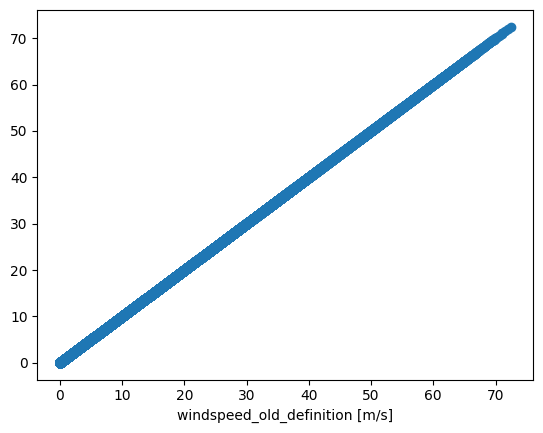

In [38]:
import matplotlib.pyplot as plt
plt.plot(df_out.sort_values(["DisNo.", "id"]).wind_speed,
         model_input.sort_values(["DisNo.", "id"]).wind_speed,
         'o')
plt.xlabel("windspeed_standardized [m/s]")
plt.xlabel("windspeed_old_definition [m/s]")
plt.show()

In [51]:
import matplotlib.pyplot as plt
aux_new = df_out.sort_values(["DisNo.", "id"])
aux_old = model_input.sort_values(["DisNo.", "id"])

In [63]:
aux_new[aux_new.sid == "2010236N12341"]

,DisNo.,GID_0,sid,id,level,Total Affected,N_events_5_years,rainfall_max_24h,perc_affected_pop_grid_region,GID_1,...,urban,rural,water,shdi,storm_tide_rp_0010,landslide_risk_sum,flood_risk,N_events_5_years_weighted,wind_speed,track_distance
17,2010-0468-ATG,ATG,2010236N12341,ATG_214,ADM1,5000.0,2.0,30.156564,0.000000,ATG.2_1,...,0.000,0.000000,0.500000,NaN,0.256,0.0,NaN,5,28.570723,136.862196
16,2010-0468-ATG,ATG,2010236N12341,ATG_309,ADM1,5000.0,2.0,29.588425,0.000000,ATG.1_1,...,0.000,0.000000,0.500000,NaN,0.401,0.0,NaN,5,30.855804,116.331700
1,2010-0468-ATG,ATG,2010236N12341,ATG_310,ADM1,5000.0,2.0,27.542749,0.000000,ATG.1_1,...,0.000,0.000000,0.500000,NaN,0.000,0.0,NaN,5,29.491802,126.938799
2,2010-0468-ATG,ATG,2010236N12341,ATG_340,ADM1,5000.0,2.0,26.724670,5.159185,ATG.4_1,...,0.000,0.005000,0.494988,NaN,0.401,0.0,NaN,5,32.423223,102.419825
3,2010-0468-ATG,ATG,2010236N12341,ATG_341,ADM1,5000.0,2.0,27.879218,5.159185,ATG.5_1,...,0.000,0.000000,0.500000,NaN,0.401,0.0,NaN,5,30.998001,113.026925
4,2010-0468-ATG,ATG,2010236N12341,ATG_342,ADM1,5000.0,2.0,31.842111,0.000000,ATG.1_1,...,0.000,0.000000,0.500000,NaN,0.000,0.0,NaN,5,29.616320,123.634025
5,2010-0468-ATG,ATG,2010236N12341,ATG_366,ADM1,5000.0,2.0,46.016949,5.159185,ATG.1_1,...,0.000,0.100000,0.399800,NaN,0.261,0.0,NaN,5,37.904266,35.472452
6,2010-0468-ATG,ATG,2010236N12341,ATG_367,ADM1,5000.0,2.0,39.870319,5.159185,ATG.1_1,...,0.000,0.210000,0.289696,NaN,0.401,0.0,NaN,5,37.642498,46.079552
7,2010-0468-ATG,ATG,2010236N12341,ATG_368,ADM1,5000.0,2.0,34.245996,5.159185,ATG.1_1,...,0.000,0.045000,0.454898,NaN,0.401,0.0,NaN,5,37.052117,56.686652
8,2010-0468-ATG,ATG,2010236N12341,ATG_372,ADM1,5000.0,2.0,27.342892,5.159185,ATG.4_1,...,0.205,0.054944,0.239688,NaN,0.401,0.0,NaN,5,32.460498,99.115051


In [65]:
aux_old[aux_old.sid == "2008287N15291"].iloc[0].wind_speed

np.float64(10.05055575349633)

In [61]:
wind_data_red[wind_data_red.sid == "2008287N15291"].iloc[0]

sid               2008287N15291
GID_0                       ATG
id                      ATG_214
wind_speed            10.050556
track_distance       216.145141
Name: 2244875, dtype: object

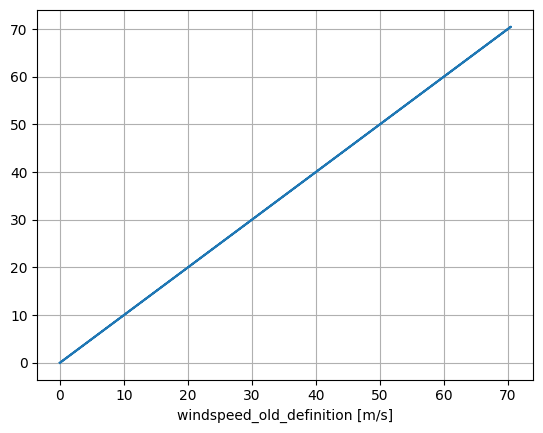

In [53]:
plt.plot(aux_new[aux_new.GID_0=="MEX"].wind_speed,
         aux_old[aux_old.GID_0=="MEX"].wind_speed,
         )
plt.xlabel("windspeed_standardized [m/s]")
plt.xlabel("windspeed_old_definition [m/s]")
plt.grid()
plt.show()